In [ ]:
# Noman Shahid 

In [6]:
pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.6 MB/s eta 0:00:0000:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu

In [21]:
from ultralytics import YOLO 
import pandas as pd 
import matplotlib.pyplot as plt 
import shutil 
import os
import cv2

In [23]:
dataset_yaml = """
path: /kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset

train: train/images
val: valid/images
test: test/images

names:
  0: first_degree
  1: second_degree
  2: third_degree
"""

with open("/kaggle/working/data_fixed.yaml", "w") as f:
    f.write(dataset_yaml)

print("Dataset YAML created successfully.")

Dataset YAML created successfully.


In [24]:
model_yaml = """
# Custom YOLOv8n + YOLOv11n backbone

nc: 3

scales:
  n: [0.33, 0.25, 1024]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 3, C3k2, [128, True, 0.25]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 6, C3k2, [256, True, 0.33]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 6, C3k2, [512, True, 0.33]]

  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 3, C3k2, [1024, True, 0.33]]

  - [-1, 1, SPPF, [1024, 5]]

head:
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 6], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]
  - [[-1, 4], 1, Concat, [1]]
  - [-1, 3, C2f, [256]]

  - [-1, 1, Conv, [256, 3, 2]]
  - [[-1, 12], 1, Concat, [1]]
  - [-1, 3, C2f, [512]]

  - [-1, 1, Conv, [512, 3, 2]]
  - [[-1, 9], 1, Concat, [1]]
  - [-1, 3, C2f, [1024]]

  - [[15, 18, 21], 1, Detect, [nc]]
"""

with open("/kaggle/working/yolov8n_v11n.yaml", "w") as f:
    f.write(model_yaml)

print("Custom model YAML created.")


Custom model YAML created.


In [25]:
model = YOLO("/kaggle/working/yolov8n_v11n.yaml")

model.info()

YOLOv8n_v11n summary: 202 layers, 2,254,289 parameters, 2,254,273 gradients, 5.6 GFLOPs


(202, 2254289, 2254273, 5.6438656)

In [27]:
results = model.train( data="/kaggle/working/data_fixed.yaml", 
                      epochs=350, 
                      imgsz=416, 
                      batch=16, 
                      device=0, 
                      workers=2, 
                      patience=30,
                      amp=True, 
                      cache=True )

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=350, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/yolov8n_v11n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [28]:
shutil.make_archive( "/kaggle/working/train_results", 
                    "zip",
                    "/kaggle/working/runs/detect/train" )
print("Training results zipped successfully.")

Training results zipped successfully.


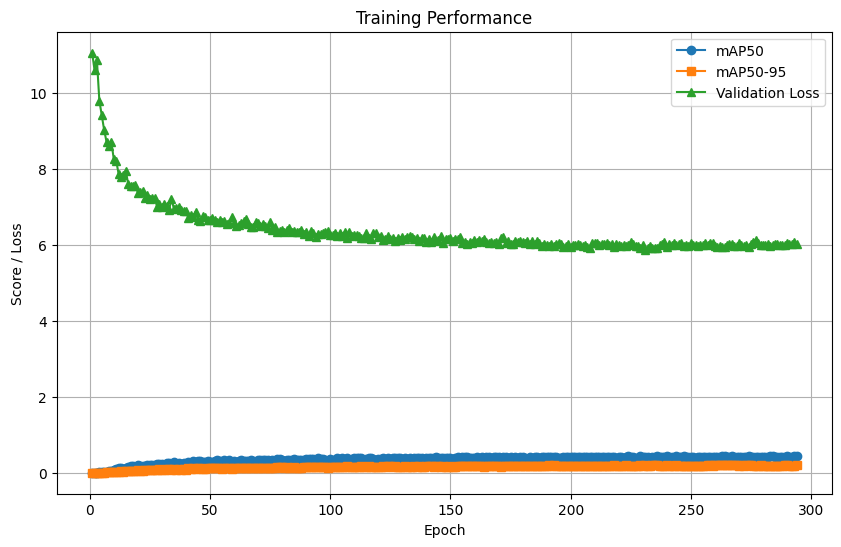

In [29]:
results_csv = "/kaggle/working/runs/detect/train/results.csv" 
df = pd.read_csv(results_csv)
df["val_loss_total"] = ( df["val/box_loss"] + df["val/cls_loss"] + df["val/dfl_loss"] ) 
plt.figure(figsize=(10, 6))
plt.plot( df["epoch"], df["metrics/mAP50(B)"], label="mAP50", marker="o" )
plt.plot( df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95", marker="s" ) 
plt.plot( df["epoch"], df["val_loss_total"], label="Validation Loss", marker="^" ) 
plt.title("Training Performance") 
plt.xlabel("Epoch") 
plt.ylabel("Score / Loss") 
plt.grid(True)
plt.legend() 
plt.show()

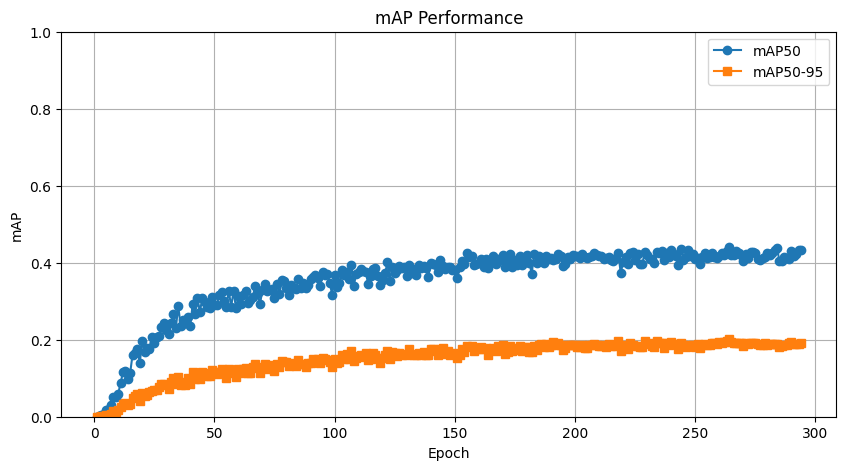

In [30]:
plt.figure(figsize=(10, 5)) 
plt.plot( df["epoch"], 
         df["metrics/mAP50(B)"], 
         label="mAP50", 
         marker="o" )

plt.plot( df["epoch"], 
         df["metrics/mAP50-95(B)"], 
         label="mAP50-95", marker="s" ) 
plt.title("mAP Performance")
plt.xlabel("Epoch")
plt.ylabel("mAP") 
plt.ylim(0, 1) 
plt.grid(True) 
plt.legend() 
plt.show()

In [34]:
image_folder = "/kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset/test/images"

In [35]:
images = os.listdir(image_folder)[:5]  # first 5 images
image_paths = [os.path.join(image_folder, img) for img in images]


image 1/1 /kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset/test/images/img1127_jpg.rf.7e3ee7c6645e220373c587b2a095616f.jpg: 416x416 1 third_degree, 9.3ms
Speed: 1.5ms preprocess, 9.3ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 416)


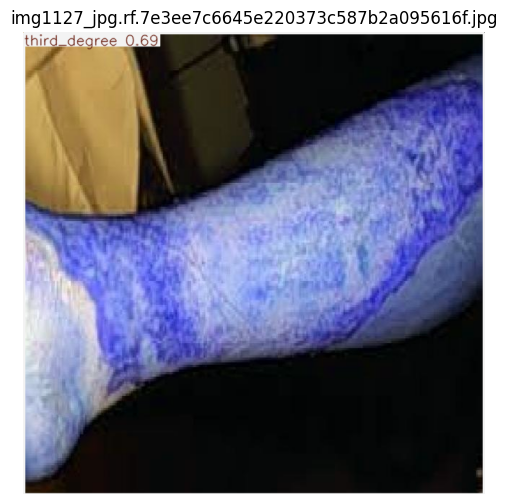


image 1/1 /kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset/test/images/img417_jpg.rf.82ba9d768061b46eaf252d640cb36787.jpg: 416x416 1 first_degree, 9.4ms
Speed: 1.5ms preprocess, 9.4ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)


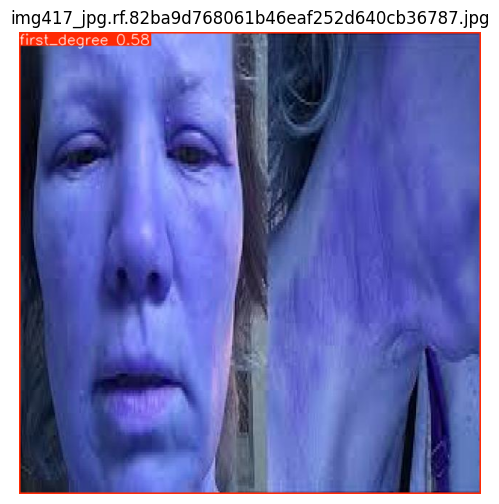


image 1/1 /kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset/test/images/img77.jpg: 352x416 1 second_degree, 63.3ms
Speed: 1.0ms preprocess, 63.3ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 416)


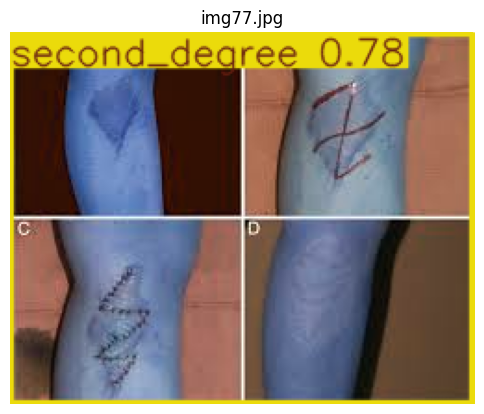


image 1/1 /kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset/test/images/img42.jpg: 416x320 1 second_degree, 1 third_degree, 56.4ms
Speed: 1.5ms preprocess, 56.4ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 320)


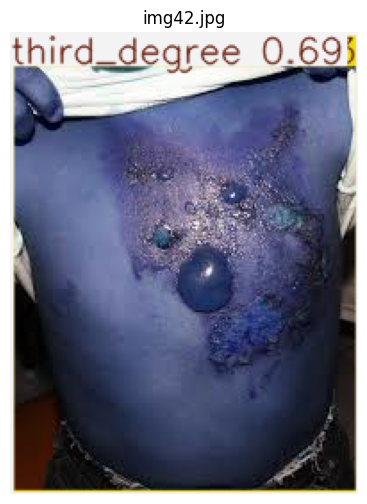


image 1/1 /kaggle/input/datasets/nomi6677/skin-burn-classification-with-degreess/basedataset/test/images/img785_jpg.rf.6fc4907c8b49f950e9fd2902e727e86a.jpg: 416x416 1 third_degree, 16.0ms
Speed: 2.1ms preprocess, 16.0ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 416)


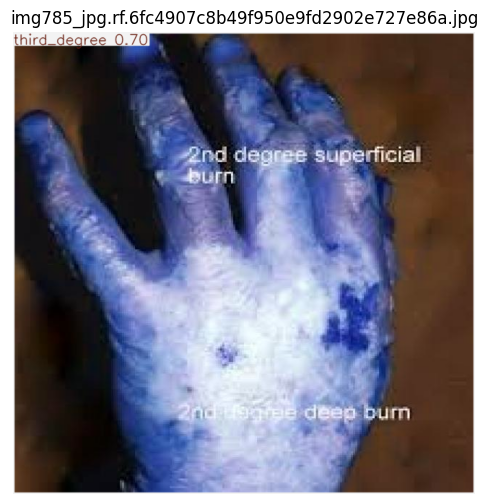

In [36]:
for img_path in image_paths:
    results = model(img_path)

    # read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # plot detections on image
    annotated_img = results[0].plot()

    plt.figure(figsize=(6,6))
    plt.imshow(annotated_img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()

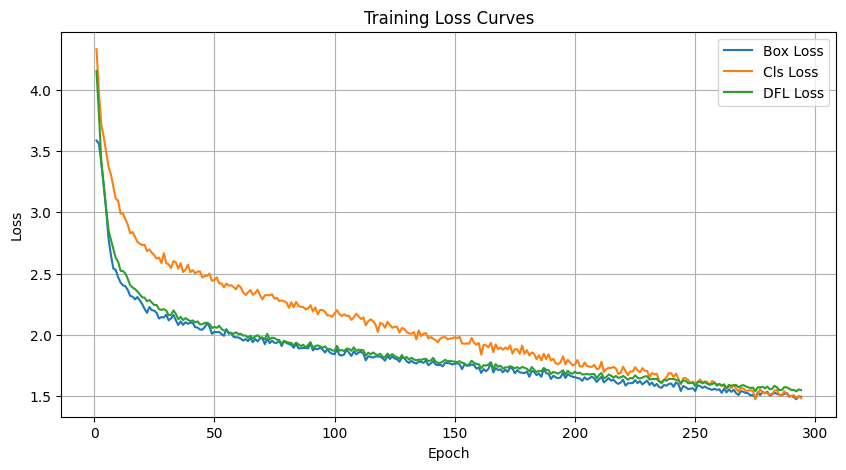

In [39]:
plt.figure(figsize=(10,5))

plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Cls Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid()
plt.show()

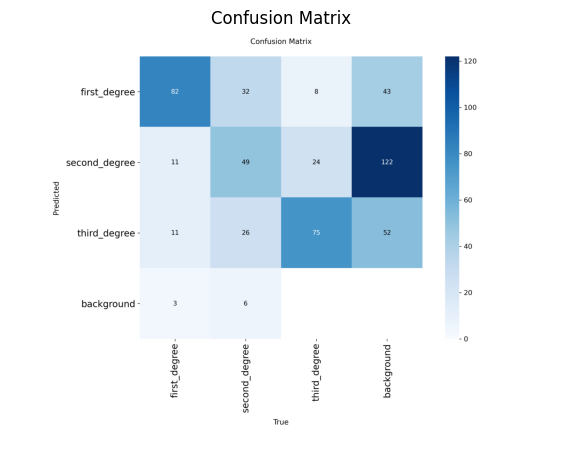

In [41]:

img = cv2.imread("/kaggle/working/runs/detect/train-3/confusion_matrix.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,7))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()